In [1]:
# Implement conditional logic to route the flow of data to different nodes. Create a router node to handle decision making and control graph flow

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [4]:
class AgentState(TypedDict):
    num1 : int
    num2 : int
    op : str
    ans : int

In [5]:
def adder(state: AgentState)-> AgentState:
    """ This Node addes two numbers """
    state["ans"] = state["num1"] + state["num2"]
    return state

def subtractor(state: AgentState)-> AgentState:
    """ This node substract 2 numbers"""
    state["ans"] = state["num1"] - state["num2"]
    return state

def decide_next_node(state: AgentState)-> AgentState:
    """ this node will decide whether the node will add or substract """
    if state["op"] == "+":
        return "addition_op"
    if state["op"] == "-":
        return "subtraction_op"

In [15]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state) # passthrough function

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge: Node
        "addition_op": "add_node",
        "subtraction_op": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

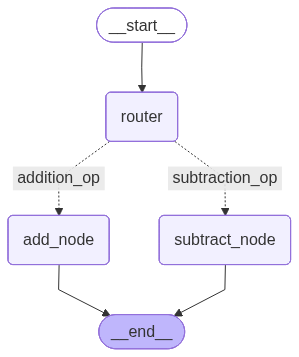

In [16]:
# Visual representation of the graph 
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
initial_state = AgentState(num1 = 21, op = "+", num2 = 36)
print(app.invoke(initial_state))

{'num1': 21, 'num2': 36, 'op': '+', 'ans': 57}
